### Classical defenition of probability

For each problem, we compute the probability combinatorially (classical definition: favorable / total), then simulate 10⁶ trials and compare with the observed frequency.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=314)
N = 10**6

In [ ]:
#1 2 dices: P(sum=11) vs P(sum=12):

rolls = rng.integers(1, 7, size=(N, 2))
sums = rolls.sum(axis=1)

p11_emp = (sums == 11).mean()
p12_emp = (sums == 12).mean()

print(f"P(11): theory {2/36:.5f}, simulation {p11_emp:.5f}")
print(f"P(12): theory {1/36:.5f}, simulation {p12_emp:.5f}")

P(11): theory 0.05556, simulation 0.05526
P(12): theory 0.02778, simulation 0.02796


The simulated and theoretical values agree to 4 decimal places.
___

In [24]:
#2 Rolling a die until it lands on a six:

M = 50
series = rng.integers(1, 7, size=(N, M))
is_six = (series == 6)

first_six_index = np.argmax(is_six, axis=1)
has_six = is_six.any(axis=1)

print(f"series without 6: {(~has_six).sum()}")
n_rolls = first_six_index[has_six] + 1

p1_emp = (n_rolls == 1).mean()
p2_emp = (n_rolls == 2).mean()
p3_emp = (n_rolls == 3).mean()

print(f"P(1): theory {1/6:.5f}, simulation {p1_emp:.5f}")
print(f"P(2): theory {5/36:.5f}, simulation {p2_emp:.5f}")
print(f"P(3): theory {25/216:.5f}, simulation {p3_emp:.5f}")

series without 6: 106
P(1): theory 0.16667, simulation 0.16645
P(2): theory 0.13889, simulation 0.13894
P(3): theory 0.11574, simulation 0.11590


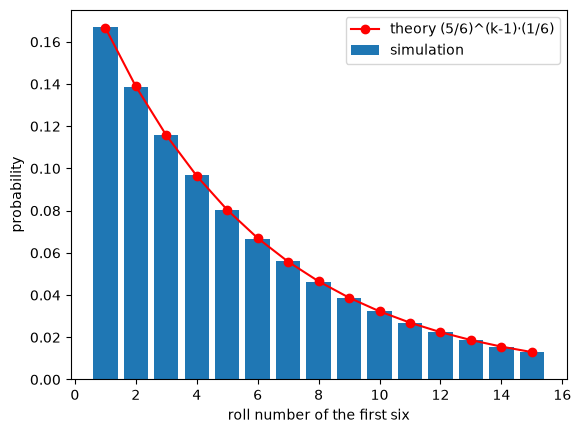

In [ ]:
counts = np.bincount(n_rolls)                 
lengths = np.arange(1, 16)
plt.bar(lengths, counts[1:16] / N, label="simulation")
plt.plot(lengths, (5/6)**(lengths - 1) * (1/6), "ro-", label="theory (5/6)^(k-1)*(1/6)")
plt.xlabel("roll number of the first six"); plt.ylabel("probability"); plt.legend()
plt.show()

Simulated frequencies match the theoretical values to the third decimal place
(e.g. P(1): 0.16667 vs 0.16682), with ~10^(-4) relative error.

The histogram shows the full picture: the empirical distribution of the first-six
roll number follows the curve P(k) = (5/6)^(k-1) * (1/6). Each bar sits on the
theoretical point, decaying geometrically by a factor of 5/6 per step. This is
the geometric distribution, obtained here empirically before its formal
introduction.

In [33]:
# and a small example demonstrating additivity of probability

x = np.array([1, 1, 1, 0, 1, 1, 0, 1, 1, 0])  

P_heads = (x == 1).mean()      
P_tails = (x == 0).mean()                
P_omega = np.isin(x, [0, 1]).mean()  

print(P_heads, P_tails, P_omega)
print("аддитивность:", P_heads + P_tails == P_omega)   

0.7 0.3 1.0
аддитивность: True
